In [12]:
import sys
print(sys.executable)
import pandas as pd
df = pd.read_csv(r"C:\Users\ojhak\OneDrive\Desktop\Python\education-state-analysis\2015_16_Statewise_Elementary.csv")
print(df.head())

c:\Users\ojhak\AppData\Local\Programs\Python\Python313\python.exe
   AC_YEAR  STATCD          STATNAME  DISTRICTS  BLOCKS  VILLAGES  CLUSTERS  \
0  2015-16       1   JAMMU & KASHMIR         22     201      7263      1628   
1  2015-16       2  HIMACHAL PRADESH         12     124     10120      2243   
2  2015-16       3            PUNJAB         22     146     13197      1780   
3  2015-16       4        CHANDIGARH          1      20        84        20   
4  2015-16       5       UTTARAKHAND         13      95     11989       995   

   TOTPOPULAT  P_URB_POP  POPULATION_0_6  ...  USCR35  NOTCH_ASS  TCHINV  \
0       12549      20.05           16.01  ...    1014      20491    1946   
1        6857       8.69           11.14  ...     652      36054    3053   
2       27704      29.82           10.62  ...    2754      88618   14200   
3        1055      97.25           11.18  ...     117       1994     218   
4       10117      21.54           13.14  ...    1147      12608    1024   

  

In [13]:
print(df.columns)

Index(['AC_YEAR', 'STATCD', 'STATNAME', 'DISTRICTS', 'BLOCKS', 'VILLAGES',
       'CLUSTERS', 'TOTPOPULAT', 'P_URB_POP', 'POPULATION_0_6',
       ...
       'USCR35', 'NOTCH_ASS', 'TCHINV', 'TOTCLS1G', 'TOTCLS2G', 'TOTCLS3G',
       'TOTCLS4G', 'TOTCLS5G', 'TOTCLS6G', 'TOTCLS7G'],
      dtype='str', length=816)


In [18]:
cols = ['STATNAME', 'TOTPOPULAT', 'P_URB_POP', 'TCHINV',
        'TOTCLS1G', 'TOTCLS2G', 'TOTCLS3G']

df_small = df[cols].copy()
df_small = df_small.dropna()

print(df_small.head())

           STATNAME  TOTPOPULAT  P_URB_POP  TCHINV  TOTCLS1G  TOTCLS2G  \
0   JAMMU & KASHMIR       12549      20.05    1946     41171     62474   
1  HIMACHAL PRADESH        6857       8.69    3053     38307      6930   
2            PUNJAB       27704      29.82   14200     56222     23531   
3        CHANDIGARH        1055      97.25     218       135       419   
4       UTTARAKHAND       10117      21.54    1024     48215     14587   

   TOTCLS3G  
0      7878  
1      6909  
2     42532  
3      2066  
4      7545  


In [21]:
df_small['total_classrooms'] = (
    df_small[['TOTCLS1G', 'TOTCLS2G', 'TOTCLS3G']]
    .fillna(0)
    .sum(axis=1)
)


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


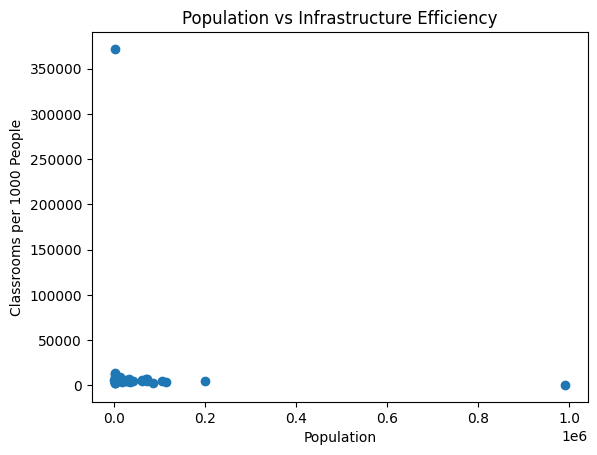

In [25]:
!pip install matplotlib
import matplotlib.pyplot as plt

df_small['classroom_per_1000'] = (
    df_small['total_classrooms'] / df_small['TOTPOPULAT']
) * 1000

plt.figure()
plt.scatter(df_small['TOTPOPULAT'], df_small['classroom_per_1000'])

plt.xlabel("Population")
plt.ylabel("Classrooms per 1000 People")
plt.title("Population vs Infrastructure Efficiency")

plt.show()

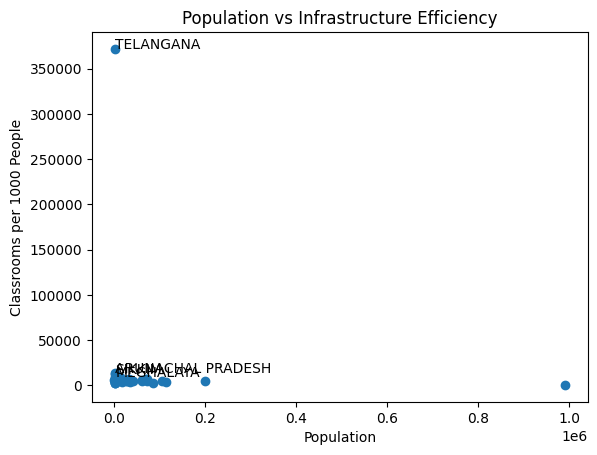

In [30]:
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(df_small['totpopulat'], df_small['classroom_per_1000'])

threshold_value = df_small['classroom_per_1000'].quantile(0.9)

for i, txt in enumerate(df_small['statname']):
    if df_small['classroom_per_1000'].iloc[i] > threshold_value:
        plt.text(
            df_small['totpopulat'].iloc[i],
            df_small['classroom_per_1000'].iloc[i],
            txt
        )

plt.xlabel("Population")
plt.ylabel("Classrooms per 1000 People")
plt.title("Population vs Infrastructure Efficiency")

plt.show()

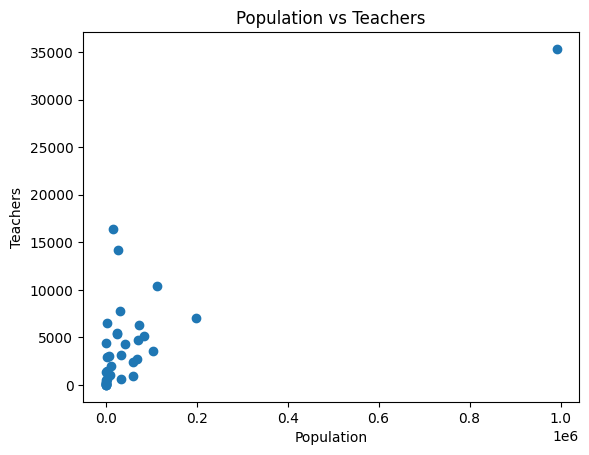

In [35]:
# normalize columns (fixes 90% of your errors)
df.columns = df.columns.str.lower()

# select required columns
cols = ['statname', 'totpopulat', 'tchinv']
df_small = df[cols].copy()

# clean data
df_small = df_small.dropna()

# plot
plt.figure()

plt.scatter(df_small['totpopulat'], df_small['tchinv'])

plt.xlabel("Population")
plt.ylabel("Teachers")
plt.title("Population vs Teachers")

plt.show()

In [40]:
print(df.columns)
print(df_small.columns)
df.columns = df.columns.str.lower()
cols = ['statname', 'totpopulat', 'p_urb_pop',
        'tchinv',
        'totcls1g', 'totcls2g', 'totcls3g']

df_small = df[cols].copy()

Index(['ac_year', 'statcd', 'statname', 'districts', 'blocks', 'villages',
       'clusters', 'totpopulat', 'p_urb_pop', 'population_0_6',
       ...
       'uscr35', 'notch_ass', 'tchinv', 'totcls1g', 'totcls2g', 'totcls3g',
       'totcls4g', 'totcls5g', 'totcls6g', 'totcls7g'],
      dtype='str', length=816)
Index(['statname', 'totpopulat', 'tchinv'], dtype='str')


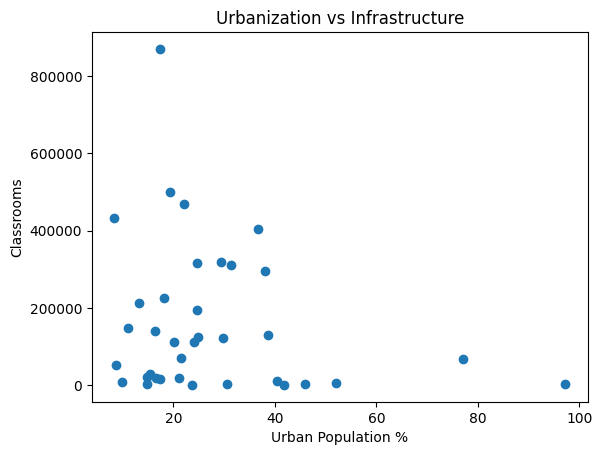

In [42]:
import matplotlib.pyplot as plt
df_small['total_classrooms'] = (
    df_small[['totcls1g', 'totcls2g', 'totcls3g']]
    .fillna(0)
    .sum(axis=1)
)
plt.figure()

plt.scatter(df_small['p_urb_pop'], df_small['total_classrooms'])

plt.xlabel("Urban Population %")
plt.ylabel("Classrooms")
plt.title("Urbanization vs Infrastructure")

plt.show()